In [1]:
import numpy as np
import pandas as pd

#TensorFlow packages for building DRNN layer
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import SimpleRNN, Dense, Input, Reshape, LSTM, BatchNormalization
from tensorflow.keras.models import Sequential

#Plotting graph
import matplotlib.pyplot as plt

#Plotting Keras Model
from tensorflow.keras.utils import plot_model

#Normalization of data
from sklearn.preprocessing import StandardScaler

#Utility Module for computing and displaying metrics
from utility_functions import metrics

import warnings
warnings.filterwarnings("ignore")

In [2]:
weather = pd.read_csv('Dataset_weather.csv',parse_dates=[0], index_col=0)

#Extracting dataset into train, validation and test sets
train = weather[:6097]
valid = weather[6097:7404]
test = weather[7404:]

scaler = StandardScaler()

#Extracting solar and wind X, y columns per set
X_solar_train = train[['SWTDN', 'SWGDN', 'T']]
y_solar_train = train['DE_solar_generation_actual']
X_solar_valid = valid[['SWTDN', 'SWGDN', 'T']]
y_solar_valid = valid['DE_solar_generation_actual']
X_solar_test = test[['SWTDN', 'SWGDN', 'T']]
y_solar_test = test['DE_solar_generation_actual']

X_wind_train = scaler.fit_transform(train[['v1', 'v2', 'v_50m', 'z0']])
y_wind_train = scaler.fit_transform(train['DE_wind_generation_actual'].values.reshape(-1,1))
X_wind_valid = scaler.fit_transform(valid[['v1', 'v2', 'v_50m', 'z0']])
y_wind_valid = scaler.fit_transform(valid['DE_wind_generation_actual'].values.reshape(-1,1))
X_wind_test = scaler.fit_transform(test[['v1', 'v2', 'v_50m', 'z0']])
y_wind_test = scaler.fit_transform(test['DE_wind_generation_actual'].values.reshape(-1,1))

In [3]:
solar_model = Sequential()
#Mapping to the input size
solar_model.add(Input(shape=(3,)))
#Reshaping for the RNN Layer to perform
solar_model.add(Reshape((-1,1)))
#Creating RNN with 100 units and TanH Activation
solar_model.add(SimpleRNN(100, activation = 'tanh', input_shape = X_solar_train.shape, return_sequences=False))
#Attaching a Dense Layer of the same unit size
solar_model.add(Dense(100))
#Batch Normalization on the output from the dense layer
solar_model.add(BatchNormalization())
#Extracting single output using Dense of 1
solar_model.add(Dense(1))
solar_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 3, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,601 (80.47 KB)

 Non-trainable params: 200 (800.00 B)

In [4]:
solar_model.compile(optimizer = 'adam', loss = 'mean_absolute_error')
history = solar_model.fit(X_solar_train, y_solar_train, epochs = 20, validation_data = (X_solar_valid, y_solar_valid))

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4677.9473 - val_loss: 3147.3943
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4590.3838 - val_loss: 3118.1064
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4564.6064 - val_loss: 3093.5195
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4631.9517 - val_loss: 3018.2390
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4416.0439 - val_loss: 3048.0481
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4467.0327 - val_loss: 2976.3152
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4327.8442 - val_loss: 2891.8501
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4310.9028 - val_loss: 2906.7739
Epoch 9/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4197.6226 - val_loss: 2726.7354
Epoch 10/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4168.3594 - val_loss: 2590.3962
Epoch 11/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4124.0786 - val_lo

In [8]:
plot_model(
    solar_model, to_file='figs/5-model.png', show_shapes=True, show_dtype=False,
    show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
)

You must install pydot (`pip install pydot`) for `plot_model` to work.


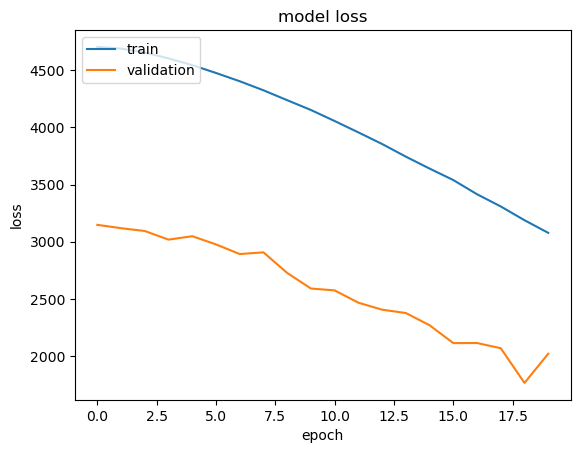

In [9]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [10]:
train_solar_pred = solar_model.predict(X_solar_train)
val_solar_pred = solar_model.predict(X_solar_valid)
test_solar_pred = solar_model.predict(X_solar_test)

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


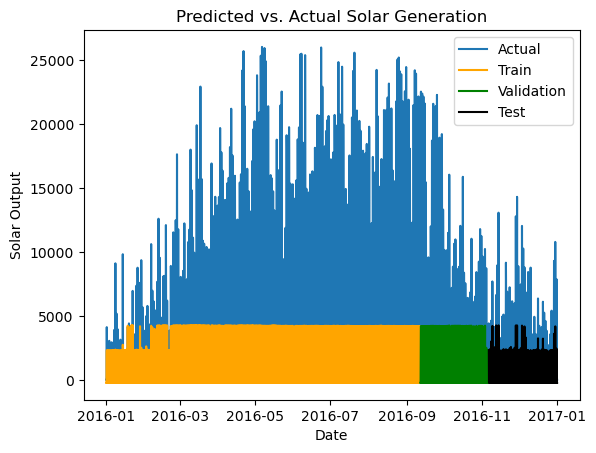

In [11]:
df = weather[['DE_solar_generation_actual']]

train_df = train[['DE_solar_generation_actual']]
train_df.loc[:, 'DE_solar_generation_actual'] = train_solar_pred

valid_df = valid[['DE_solar_generation_actual']]
valid_df.loc[:, 'DE_solar_generation_actual'] = val_solar_pred

test_df = test[['DE_solar_generation_actual']]
test_df.loc[:, 'DE_solar_generation_actual'] = test_solar_pred

# Plot all predictions
inversetransform, =plt.plot(df, label = 'Actual')
train_solar_predx, =plt.plot(train_df, color='orange', label = 'Train')
val_solar_predx, =plt.plot(valid_df, color='green', label = 'Validation')
test_solar_predx, =plt.plot(test_df, color='black', label = 'Test')
plt.xlabel('Date')
plt.ylabel('Solar Output')
plt.legend(loc="upper right")
plt.title("Predicted vs. Actual Solar Generation")
plt.show()

In [12]:
metrics('drnn', test[['DE_solar_generation_actual']], test_solar_pred)

,MAE,MSE,RMSE,RMSLE,R2
model,,,,,
drnn,810.770473,2.571951e+06,1603.730199,7.380711,0.53631


In [13]:
wind_model = Sequential()
wind_model.add(Input(shape=(4,)))
wind_model.add(Reshape((-1,1)))
wind_model.add(SimpleRNN(100, activation = 'tanh', input_shape = X_wind_train.shape, return_sequences=False))
wind_model.add(Dense(100))
wind_model.add(BatchNormalization())
wind_model.add(Dense(1))
wind_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 100)            │        10,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,601 (80.47 KB)

 Non-trainable params: 200 (800.00 B)

In [14]:
wind_model.compile(optimizer = 'adam', loss = 'mean_squared_error')
history = wind_model.fit(X_wind_train, y_wind_train, validation_data=(X_wind_valid, y_wind_valid), epochs=20)

Epoch 1/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2398 - val_loss: 0.3406
Epoch 2/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1219 - val_loss: 0.2411
Epoch 3/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1026 - val_loss: 0.1149
Epoch 4/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1089 - val_loss: 0.2058
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1071 - val_loss: 0.1420
Epoch 6/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0979 - val_loss: 0.1414
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1024 - val_loss: 0.1135
Epoch 8/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1106 - val_loss: 0.1382
Epoch 9/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1072 - val_loss: 0.1607
Epoch 10/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0990 - val_loss: 0.1427
Epoch 11/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0999 - val_loss: 0.1719
Epoch 12/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

In [15]:
wind_model.evaluate(X_wind_test, y_wind_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0929 


0.08251548558473587

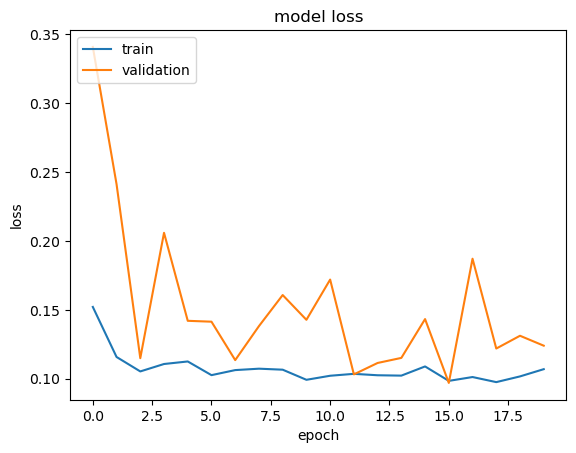

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

In [17]:
train_wind_pred = wind_model.predict(X_wind_train)
val_wind_pred = wind_model.predict(X_wind_valid)
test_wind_pred = wind_model.predict(X_wind_test)

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


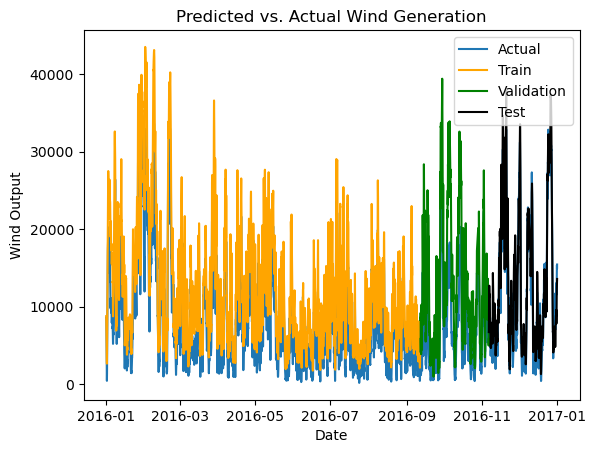

In [18]:
df = weather[['DE_wind_generation_actual']]

train_df = train[['DE_wind_generation_actual']]
train_df.loc[:, 'DE_wind_generation_actual'] = scaler.inverse_transform(train_wind_pred)

valid_df = valid[['DE_wind_generation_actual']]
valid_df.loc[:, 'DE_wind_generation_actual'] = scaler.inverse_transform(val_wind_pred)

test_df = test[['DE_wind_generation_actual']]
test_df.loc[:, 'DE_wind_generation_actual'] = scaler.inverse_transform(test_wind_pred)

# Plot all predictions
inversetransform, =plt.plot(df, label = 'Actual')
train_wind_predx, =plt.plot(train_df, color='orange', label = 'Train')
val_wind_predx, =plt.plot(valid_df, color='green', label = 'Validation')
test_wind_predx, =plt.plot(test_df, color='black', label = 'Test')
plt.xlabel('Date')
plt.ylabel('Wind Output')
plt.legend(loc="upper right")
plt.title("Predicted vs. Actual Wind Generation")
plt.show()

In [19]:
metrics('drnn', test[['DE_wind_generation_actual']], scaler.inverse_transform(test_wind_pred))

,MAE,MSE,RMSE,RMSLE,R2
model,,,,,
drnn,1994.808212,6.166263e+06,2483.196197,7.817704,0.917485
